# GenAssist: Generative AI Customer Support Avatar


## 1. Install and clone the project


In [ ]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

IN_COLAB = importlib.util.find_spec("google.colab") is not None
ROOT = Path("/content") if IN_COLAB else Path.cwd()
DREAMTALK_DIR = ROOT / "dreamtalk"

packages = [
    "accelerate",
    "av",
    "diffusers",
    "dlib-bin",
    "ffmpeg-python",
    "gTTS",
    "gradio",
    "imageio",
    "librosa",
    "opencv-python",
    "PyYAML",
    "safetensors",
    "scikit-image",
    "scikit-learn",
    "soundfile",
    "transformers",
    "urllib3<2",
    "yacs==0.1.8",
]

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", *packages],
    check=True,
)

if not DREAMTALK_DIR.exists():
    subprocess.run(
        ["git", "clone", "https://github.com/ali-vilab/dreamtalk.git", str(DREAMTALK_DIR)],
        check=True,
    )
else:
    print(f"Using existing DreamTalk checkout: {DREAMTALK_DIR}")

if not (DREAMTALK_DIR / "inference_for_demo_video.py").exists():
    raise FileNotFoundError("DreamTalk clone is incomplete. Delete its folder and rerun this cell.")

print("Setup complete.")


Setup complete.


## 2. Configure the customer-support response


In [ ]:
import torch
from IPython.display import Audio, Video, display

SUPPORT_TEXT = (
    "Hello! Welcome to GenAssist customer support. "
    "I am your virtual assistant. Please describe your issue, "
    "and I will help you find the best solution."
)

AVATAR_PROMPT = (
    "professional friendly customer support representative, realistic headshot, "
    "front-facing, neutral background, studio lighting, symmetrical face, "
    "looking directly at the camera, closed mouth"
)

OUTPUT_NAME = "genassist_customer_support"
IMAGE_PATH = DREAMTALK_DIR / "data" / "src_img" / "uncropped" / "generated_avatar.png"
AUDIO_PATH = DREAMTALK_DIR / "data" / "audio" / "generated_voice.wav"
VIDEO_PATH = DREAMTALK_DIR / "output_video" / f"{OUTPUT_NAME}.mp4"

IMAGE_PATH.parent.mkdir(parents=True, exist_ok=True)
AUDIO_PATH.parent.mkdir(parents=True, exist_ok=True)
VIDEO_PATH.parent.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
print("Response:", SUPPORT_TEXT)


Device: cuda
Response: Hello! Welcome to GenAssist customer support. I am your virtual assistant. Please describe your issue, and I will help you find the best solution.


## 3. Create the avatar

Set `GENERATE_WITH_AI = False` to upload your own front-facing portrait. A portrait
larger than 256 x 256 pixels gives DreamTalk the best input.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/30 [00:00<?, ?it/s]

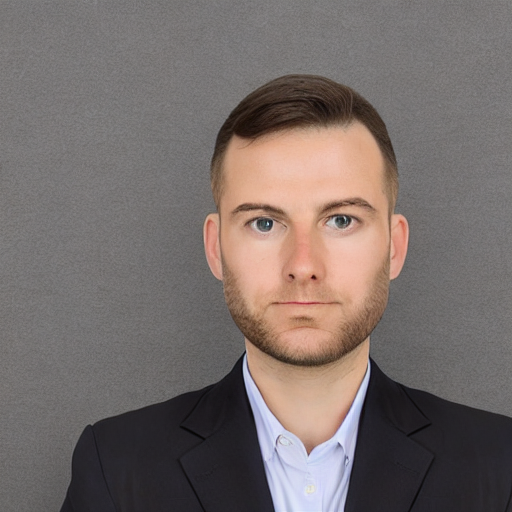

Avatar saved to /content/dreamtalk/data/src_img/uncropped/generated_avatar.png


In [ ]:
from PIL import Image

GENERATE_WITH_AI = True
AVATAR_MODEL = "runwayml/stable-diffusion-v1-5"

if GENERATE_WITH_AI:
    if DEVICE != "cuda":
        raise RuntimeError(
            "AI image generation needs a GPU. Enable a Colab GPU, or set "
            "GENERATE_WITH_AI = False and upload a portrait."
        )

    from diffusers import StableDiffusionPipeline

    pipe = StableDiffusionPipeline.from_pretrained(
        AVATAR_MODEL,
        torch_dtype=torch.float16,
        safety_checker=None,
    ).to(DEVICE)
    pipe.enable_attention_slicing()

    avatar = pipe(
        AVATAR_PROMPT,
        negative_prompt=(
            "side profile, tilted head, open mouth, teeth, multiple people, "
            "blurry, low quality, deformed face"
        ),
        num_inference_steps=30,
        guidance_scale=7.5,
    ).images[0]
    avatar = avatar.convert("RGB").resize((512, 512))
    avatar.save(IMAGE_PATH)

    del pipe
    torch.cuda.empty_cache()
else:
    if not IN_COLAB:
        raise RuntimeError(f"Place a portrait at {IMAGE_PATH} and rerun this cell.")

    from google.colab import files

    uploaded = files.upload()
    if not uploaded:
        raise RuntimeError("No portrait was uploaded.")
    uploaded_name, uploaded_bytes = next(iter(uploaded.items()))
    upload_path = ROOT / uploaded_name
    upload_path.write_bytes(uploaded_bytes)
    avatar = Image.open(upload_path).convert("RGB")
    if min(avatar.size) < 256:
        raise ValueError("The portrait must be at least 256 x 256 pixels.")
    avatar.save(IMAGE_PATH)

display(avatar)
print(f"Avatar saved to {IMAGE_PATH}")


## 4. Convert the response to speech


In [ ]:
from gtts import gTTS
import tempfile

LANGUAGE = "en"
with tempfile.NamedTemporaryFile(suffix=".mp3", delete=False) as temporary_audio:
    temporary_mp3 = Path(temporary_audio.name)

try:
    gTTS(text=SUPPORT_TEXT, lang=LANGUAGE, slow=False).save(str(temporary_mp3))
    conversion = subprocess.run(
        [
            "ffmpeg",
            "-y",
            "-i",
            str(temporary_mp3),
            "-ac",
            "1",
            "-ar",
            "16000",
            str(AUDIO_PATH),
        ],
        capture_output=True,
        text=True,
    )
    if conversion.returncode != 0:
        raise RuntimeError("Audio conversion failed:\n" + conversion.stderr[-2000:])
finally:
    temporary_mp3.unlink(missing_ok=True)

if not AUDIO_PATH.exists() or AUDIO_PATH.stat().st_size == 0:
    raise RuntimeError("Speech generation did not create a valid audio file.")

display(Audio(filename=str(AUDIO_PATH)))
print(f"Speech saved to {AUDIO_PATH}")


Speech saved to /content/dreamtalk/data/audio/generated_voice.wav


## 5. Add the DreamTalk checkpoint



In [ ]:
import shutil
import zipfile

CHECKPOINT_DIR = DREAMTALK_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

def checkpoint_files():
    return [
        path for path in CHECKPOINT_DIR.rglob("*")
        if path.is_file() and path.name != ".gitkeep" and path.stat().st_size > 1024
    ]

if not checkpoint_files():
    if not IN_COLAB:
        print(f"Place the official DreamTalk checkpoint files in: {CHECKPOINT_DIR}")
    else:
        from google.colab import files

        print("Upload the official DreamTalk checkpoint file or ZIP archive.")
        uploaded = files.upload()
        for name, data in uploaded.items():
            destination = CHECKPOINT_DIR / Path(name).name
            destination.write_bytes(data)
            if zipfile.is_zipfile(destination):
                with zipfile.ZipFile(destination) as archive:
                    archive.extractall(CHECKPOINT_DIR)
                destination.unlink()

found_checkpoints = checkpoint_files()
if not found_checkpoints:
    raise FileNotFoundError(
        "DreamTalk checkpoint is missing. Request it from the authors using the "
        "official repository instructions, place it in the checkpoints folder, "
        "then rerun this cell."
    )

print("Checkpoint files:")
for path in found_checkpoints:
    print(" -", path.relative_to(DREAMTALK_DIR))


Upload the official DreamTalk checkpoint file or ZIP archive.


Saving renderer (1).pt to renderer (1).pt
Saving denoising_network (2).pth to denoising_network (2).pth
Checkpoint files:
 - checkpoints/archive/data.pkl
 - checkpoints/archive/data/94741173156720
 - checkpoints/archive/data/94741133795168
 - checkpoints/archive/data/94740477789392
 - checkpoints/archive/data/93951776455088
 - checkpoints/archive/data/93951775628624
 - checkpoints/archive/data/94741172834672
 - checkpoints/archive/data/93951776439248
 - checkpoints/archive/data/94741173082192
 - checkpoints/archive/data/94741172356336
 - checkpoints/archive/data/93951775615824
 - checkpoints/archive/data/94740510934304
 - checkpoints/archive/data/94740525926864
 - checkpoints/archive/data/93951776392272
 - checkpoints/archive/data/94741136509360
 - checkpoints/archive/data/94740490171344
 - checkpoints/archive/data/94741172370800
 - checkpoints/archive/data/94740471397392
 - checkpoints/archive/data/94740525994192
 - checkpoints/archive/data/94740561895200
 - checkpoints/archive/data/9

In [ ]:
!pip install imageio imageio-ffmpeg

## 6. Validate inputs and generate the talking-avatar video


In [ ]:
STYLE_PATH = (
    DREAMTALK_DIR
    / "data"
    / "style_clip"
    / "3DMM"
    / "M030_front_neutral_level1_001.mat"
)
POSE_PATH = (
    DREAMTALK_DIR
    / "data"
    / "pose"
    / "RichardShelby_front_neutral_level1_001.mat"
)
INFERENCE_SCRIPT = DREAMTALK_DIR / "inference_for_demo_video.py"

required_inputs = {
    "inference script": INFERENCE_SCRIPT,
    "avatar image": IMAGE_PATH,
    "speech audio": AUDIO_PATH,
    "style reference": STYLE_PATH,
    "pose reference": POSE_PATH,
}
missing = [f"{label}: {path}" for label, path in required_inputs.items() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required input(s):\n" + "\n".join(missing))
if not checkpoint_files():
    raise FileNotFoundError(f"No DreamTalk checkpoint found in {CHECKPOINT_DIR}")

command = [
    sys.executable,
    str(INFERENCE_SCRIPT),
    "--wav_path",
    str(AUDIO_PATH),
    "--style_clip_path",
    str(STYLE_PATH),
    "--pose_path",
    str(POSE_PATH),
    "--image_path",
    str(IMAGE_PATH),
    "--cfg_scale",
    "1.0",
    "--max_gen_len",
    "30",
    "--output_name",
    OUTPUT_NAME,
]
if DEVICE == "cpu":
    command.extend(["--device", "cpu"])

print("Generating video. This can take several minutes...")
result = subprocess.run(
    command,
    cwd=DREAMTALK_DIR,
    capture_output=True,
    text=True,
)

if result.stdout:
    print("--- DreamTalk output ---")
    print(result.stdout[-6000:])

if result.returncode != 0:
    print("--- DreamTalk error ---")
    print(result.stderr[-6000:])
    raise RuntimeError(
        "DreamTalk failed. Read the detailed error printed directly above. "
        "Common causes are an incorrect checkpoint layout, a missing model file, "
        "or incompatibility with the current Colab Python/PyTorch versions."
    )

if not VIDEO_PATH.exists() or VIDEO_PATH.stat().st_size == 0:
    raise RuntimeError(f"DreamTalk finished but did not create {VIDEO_PATH}")

print(f"Video created: {VIDEO_PATH}")
display(Video(str(VIDEO_PATH), embed=True))


Generating video. This can take several minutes...
Video created: /content/dreamtalk/output_video/genassist_customer_support.mp4


In [ ]:
from pathlib import Path

videos = list(Path("/content/dreamtalk/output_video").glob("*.mp4"))
videos

[]

In [ ]:
import requests

GENASSIST_URL = "https://your-ngrok-url.ngrok-free.app"
RUN_ID = "paste_colab_run_id_from_frontend"

with open(str(VIDEO_PATH), "rb") as video_file:
    response = requests.post(
        f"{GENASSIST_URL}/api/runs/{RUN_ID}/video",
        files={"video": ("response.mp4", video_file, "video/mp4")},
    )

print(response.status_code)
print(response.text)

NameError: name 'VIDEO_PATH' is not defined

## Project notes

- Use only portraits you have permission to animate.
- Clearly disclose to users that the support avatar is AI-generated.
- DreamTalk is intended for research/non-commercial use; review its license and
  checkpoint terms before deployment.
- A production version should add a real support knowledge base or language model,
  moderation, multilingual TTS, logging, and a web interface.
